# Fourier Transform

The Fourier transform decomposes a signal into its constituent frequency components, providing an alternative representation in the frequency domain. While the time domain describes how a signal evolves over time, the frequency domain reveals the amplitudes and frequencies that compose the signal. Fourier analysis is fundamental in computational physics and is widely applied to signal processing, spectroscopy, quantum mechanics, optics, and the numerical solution of partial differential equations.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq, fftshift

In [11]:
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

## Time-Domain Signal

As an example, consider a Gaussian-modulated sinusoidal signal,

$$
x(t)=\exp\left(-\frac{(t-t_0)^2}{2\sigma^2}\right)\sin(2\pi f_0 t),
$$

where $f_0$ is the carrier frequency, $t_0$ is the center of the Gaussian envelope, and $\sigma$ controls the temporal width of the pulse.

In [12]:
fs, T = 1000, 2
f0, t0, sigma = 10, 1, 0.2

In [13]:
t = np.linspace(0, T, fs*T)
x = np.exp(-(t - t0)**2 / (2*sigma**2)) * np.sin(2*np.pi*f0*t)

The generated signal is first visualized in the time domain before performing the Fourier transform.

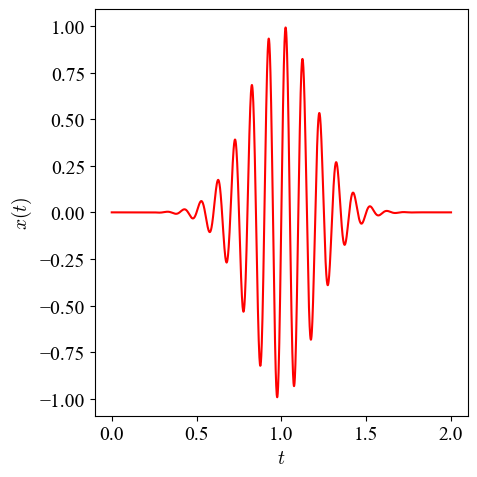

In [14]:
plt.figure(figsize=(5, 5))
plt.plot(t, x, color="r")
plt.xlabel(r"$t$")
plt.ylabel(r"$x(t)$")
plt.tight_layout()
plt.show()

## Continuous Fourier Transform

The continuous Fourier transform converts a continuous-time signal into its frequency-domain representation,

$$
X(f)=\int_{-\infty}^{\infty}x(t)e^{-i2\pi ft}\,dt,
$$

where $X(f)$ denotes the complex spectrum of the signal. The original signal can be reconstructed using the inverse Fourier transform,

$$
x(t)=\int_{-\infty}^{\infty}X(f)e^{i2\pi ft}\,df.
$$

These continuous formulations provide the mathematical foundation for spectral analysis

## Discrete Fourier Transform

For sampled data, the Fourier transform is approximated by the discrete Fourier transform (DFT),

$$
X_k=\sum_{n=0}^{N-1}x_n e^{-i2\pi kn/N},\qquad k=0,\ldots,N-1,
$$

where $N$ is the number of samples. The inverse discrete Fourier transform (IDFT) reconstructs the original signal,

$$
x_n=\frac{1}{N}\sum_{k=0}^{N-1}X_k e^{i2\pi kn/N}.
$$

Direct evaluation of the DFT requires $O(N^2)$ operations. In practice, the Fast Fourier Transform (FFT) computes the same result with a computational complexity of $O(N\log{N})$, making spectral analysis efficient for large datasets.

## Fast Fourier Transform

The following code computes the discrete Fourier transform using `scipy.fft.fft`, shifts the zero-frequency component to the center of the spectrum using `fftshift`, and constructs the corresponding frequency axis using `fftfreq`.

In [15]:
X = fft(x)
X_shift = fftshift(X)
freqs = fftfreq(len(x), 1/fs)
freqs_shift = fftshift(freqs)

The magnitude spectrum $|X(f)|$, illustrates the distribution of the signal energy across different frequency components. Peaks in the spectrum indicate the dominant frequencies present in the original signal.

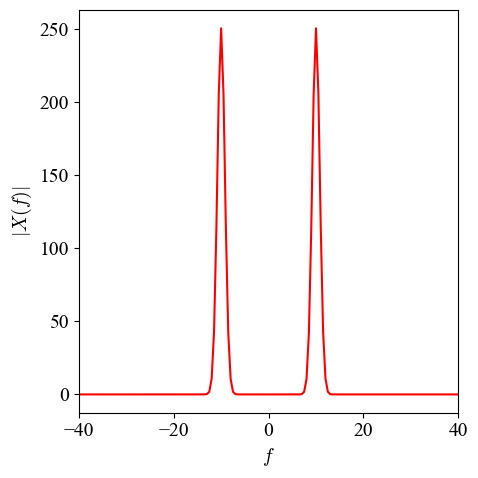

In [16]:
plt.figure(figsize=(5, 5))
plt.plot(freqs_shift, np.abs(X_shift), color="r")
plt.xlabel(r"$f$")
plt.ylabel(r"$|X(f)|$")
plt.xlim(-40, 40)
plt.tight_layout()
plt.show()

## Inverse Fast Fourier Transform

The original signal is reconstructed using the inverse Fast Fourier Transform (IFFT),

$$
x(t)=\mathrm{IFFT}\left(\mathrm{FFT}(x)\right),
$$

demonstrating that the frequency-domain representation preserves all information required to recover the original signal, up to numerical round-off errors.

In [17]:
x_rec = ifft(X)

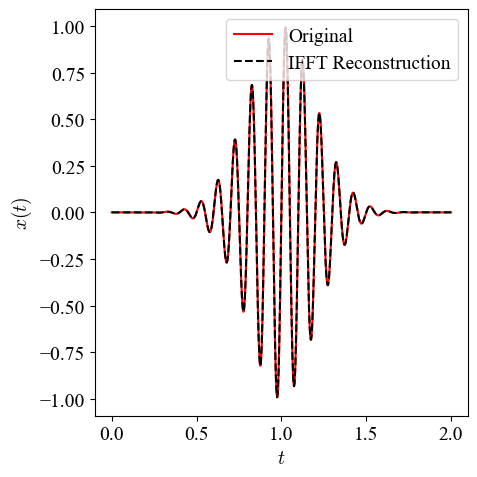

In [18]:
plt.figure(figsize=(5, 5))
plt.plot(t, x, color="r", label="Original")
plt.plot(t, x_rec.real, "--", color="k", label="IFFT Reconstruction")
plt.xlabel(r"$t$")
plt.ylabel(r"$x(t)$")
plt.legend()
plt.tight_layout()
plt.show()

## Key Insights

* The Fourier transform converts signals from the time domain to the frequency domain.
* The continuous Fourier transform provides the mathematical foundation, while the DFT enables numerical computation for sampled data.
* The FFT computes the DFT efficiently with $O(N\log{N})$ complexity.
* The magnitude spectrum reveals the dominant frequency components of a signal.
* Applying the inverse FFT reconstructs the original signal, demonstrating that the frequency-domain representation retains complete information.